<a href="https://colab.research.google.com/github/madhanr27/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Major Project: Seasonal Agriculture Performance Analysis

This notebook performs the complete workflow requested in the project brief:
**data understanding → cleaning → seasonal analysis → crop/region/resource comparisons → relationships → statistical testing → visualization → conclusions and recommendations.**


## 1. Load dataset

In [ ]:
!pip -q install scipy seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)
display(df.head())


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
print("Rows, Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

for col in ["State","District","Crop","Season","Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()} unique values")


Rows, Columns: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


State: 8 unique values
District: 10 unique values
Crop: 8 unique values
Season: 3 unique values
Irrigation_Method: 4 unique values


## 2. Data quality and cleaning

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": (missing / len(df) * 100).round(2)
})
display(missing_report[missing_report["Missing_Count"] > 0])
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Duplicate rows: 0
Duplicate Farm_IDs: 0


In [ ]:
# Median imputation for missing numeric values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", int(df.isnull().sum().sum()))
display(df.describe().T)


Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 3. Seasonal performance

In [ ]:
season_summary = df.groupby("Season").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha","mean"),
    Avg_Production_Tonnes=("Production_Tonnes","mean"),
    Avg_Revenue_INR=("Revenue_INR","mean"),
    Avg_Cost_INR=("Total_Cost_INR","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct","mean"),
    Avg_Rainfall_mm=("Rainfall_mm","mean")
).round(2)
display(season_summary)


,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_Rainfall_mm
Season,,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,531804.41,178914.65,5.89,54.47,849.20
Rabi,1627,5.04,41.49,601526.05,513836.58,87689.47,5.19,40.48,437.62
Zaid,594,4.64,38.89,519171.90,543976.73,-24804.82,4.41,38.22,304.65


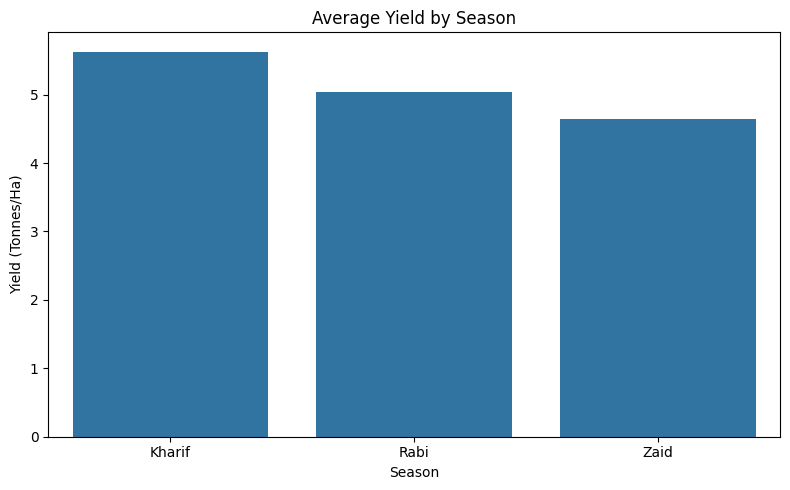

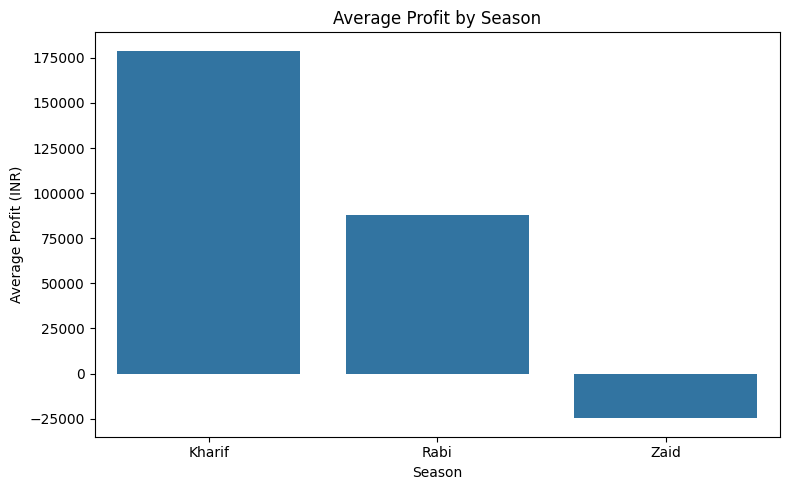

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield by Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit by Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()


## 4. Crop-wise analysis

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


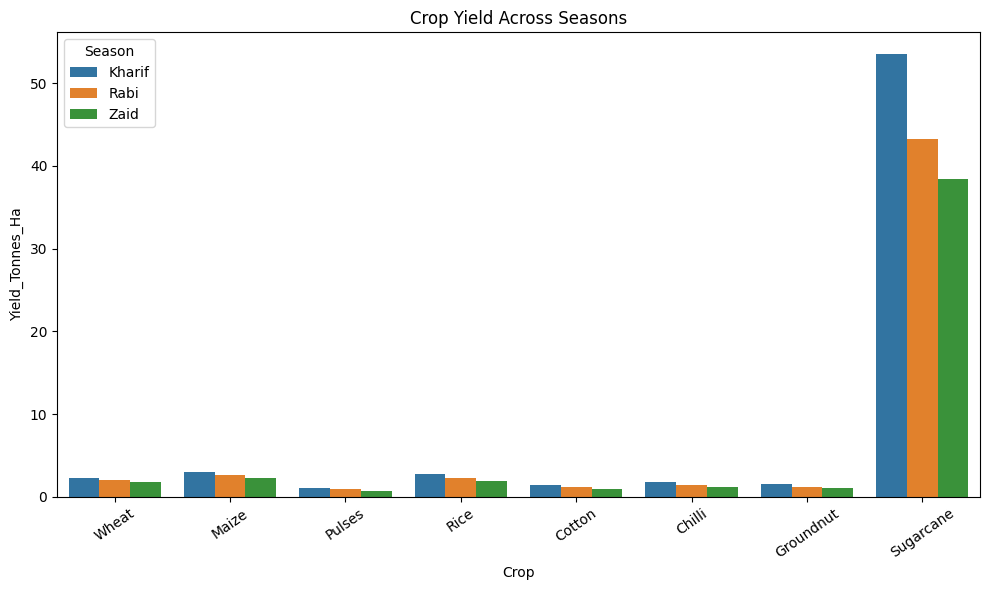

In [ ]:
crop_season_yield = df.pivot_table(
    index="Crop", columns="Season",
    values="Yield_Tonnes_Ha", aggfunc="mean"
).round(2)
display(crop_season_yield)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", errorbar=None)
plt.title("Crop Yield Across Seasons")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


,Average_Profit_INR
Crop,
Sugarcane,817187.99
Chilli,750878.34
Cotton,124546.92
Groundnut,44858.12
Pulses,-4238.05
Maize,-83978.33
Rice,-102213.50
Wheat,-123398.34


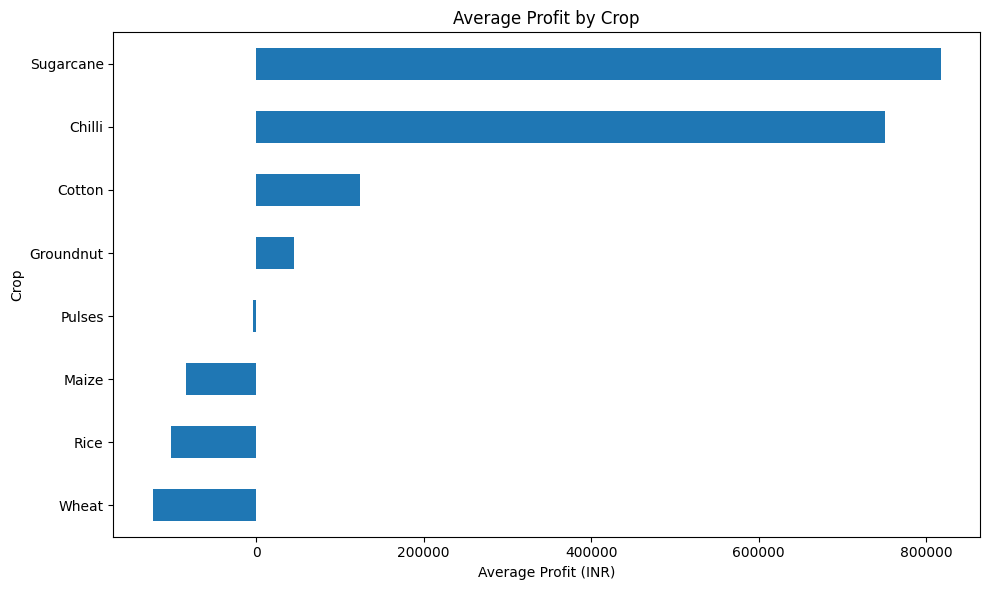

In [ ]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False).round(2)
display(crop_profit.to_frame("Average_Profit_INR"))

plt.figure(figsize=(10,6))
crop_profit.sort_values().plot(kind="barh")
plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.tight_layout()
plt.show()


## 5. Irrigation and resource usage

In [ ]:
irrigation_summary = df.groupby("Irrigation_Method").agg(
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Used=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Yield", ascending=False).round(2)
display(irrigation_summary)


,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,
Drip,6.58,219626.00,5918.75,6.27
Sprinkler,5.16,91121.08,6208.26,4.67
Flood,4.86,73354.02,8026.47,3.44
Rainfed,4.60,79050.37,3549.55,7.56


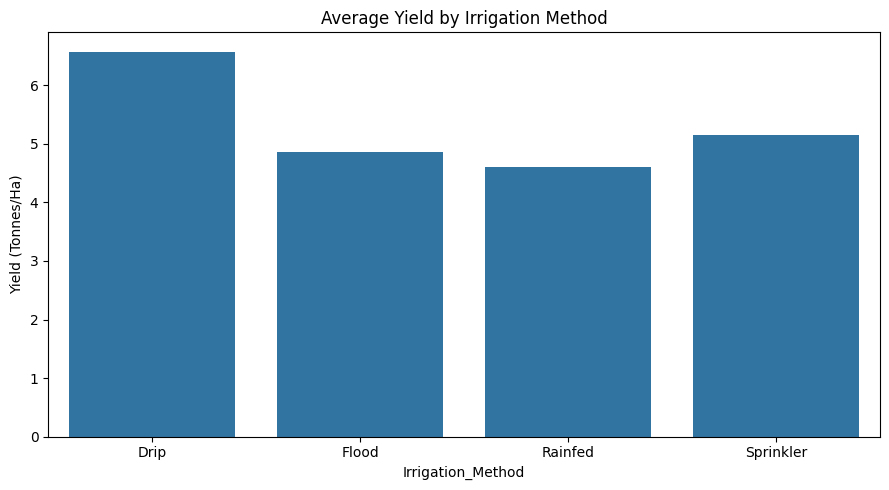

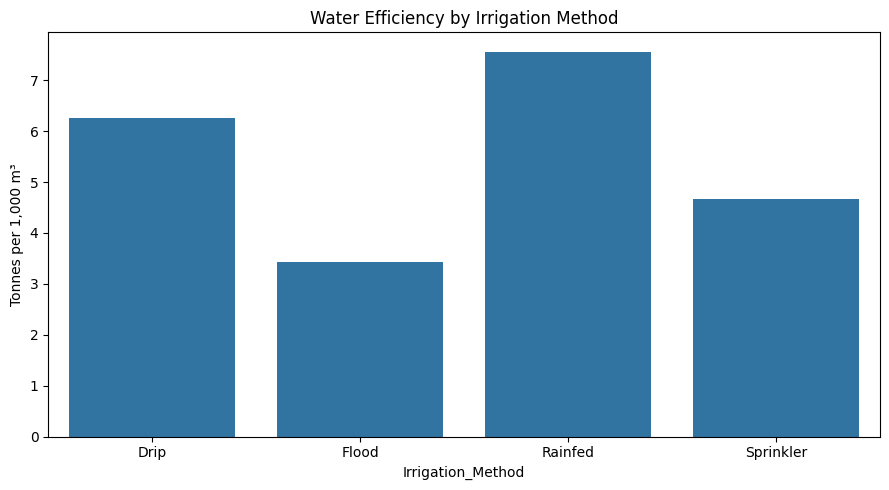

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield by Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.barplot(data=df, x="Irrigation_Method",
            y="Water_Efficiency_t_per_1000m3", errorbar=None)
plt.title("Water Efficiency by Irrigation Method")
plt.ylabel("Tonnes per 1,000 m³")
plt.tight_layout()
plt.show()


## 6. Regional comparison

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


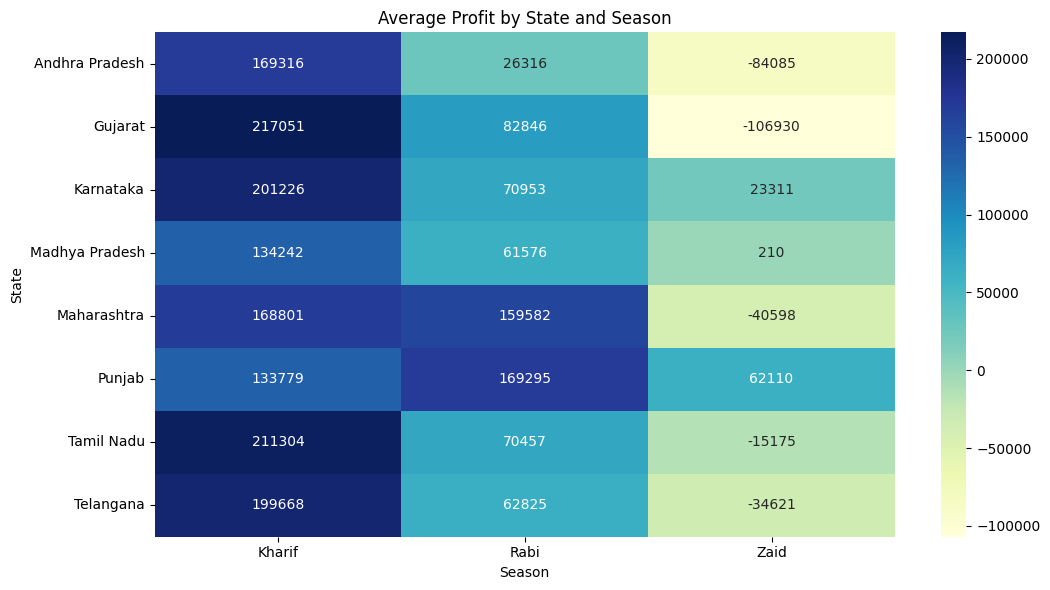

In [ ]:
state_season_profit = df.pivot_table(
    index="State", columns="Season",
    values="Profit_INR", aggfunc="mean"
).round(0)
display(state_season_profit)

plt.figure(figsize=(11,6))
sns.heatmap(state_season_profit, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Profit by State and Season")
plt.tight_layout()
plt.show()


## 7. Correlation and relationships

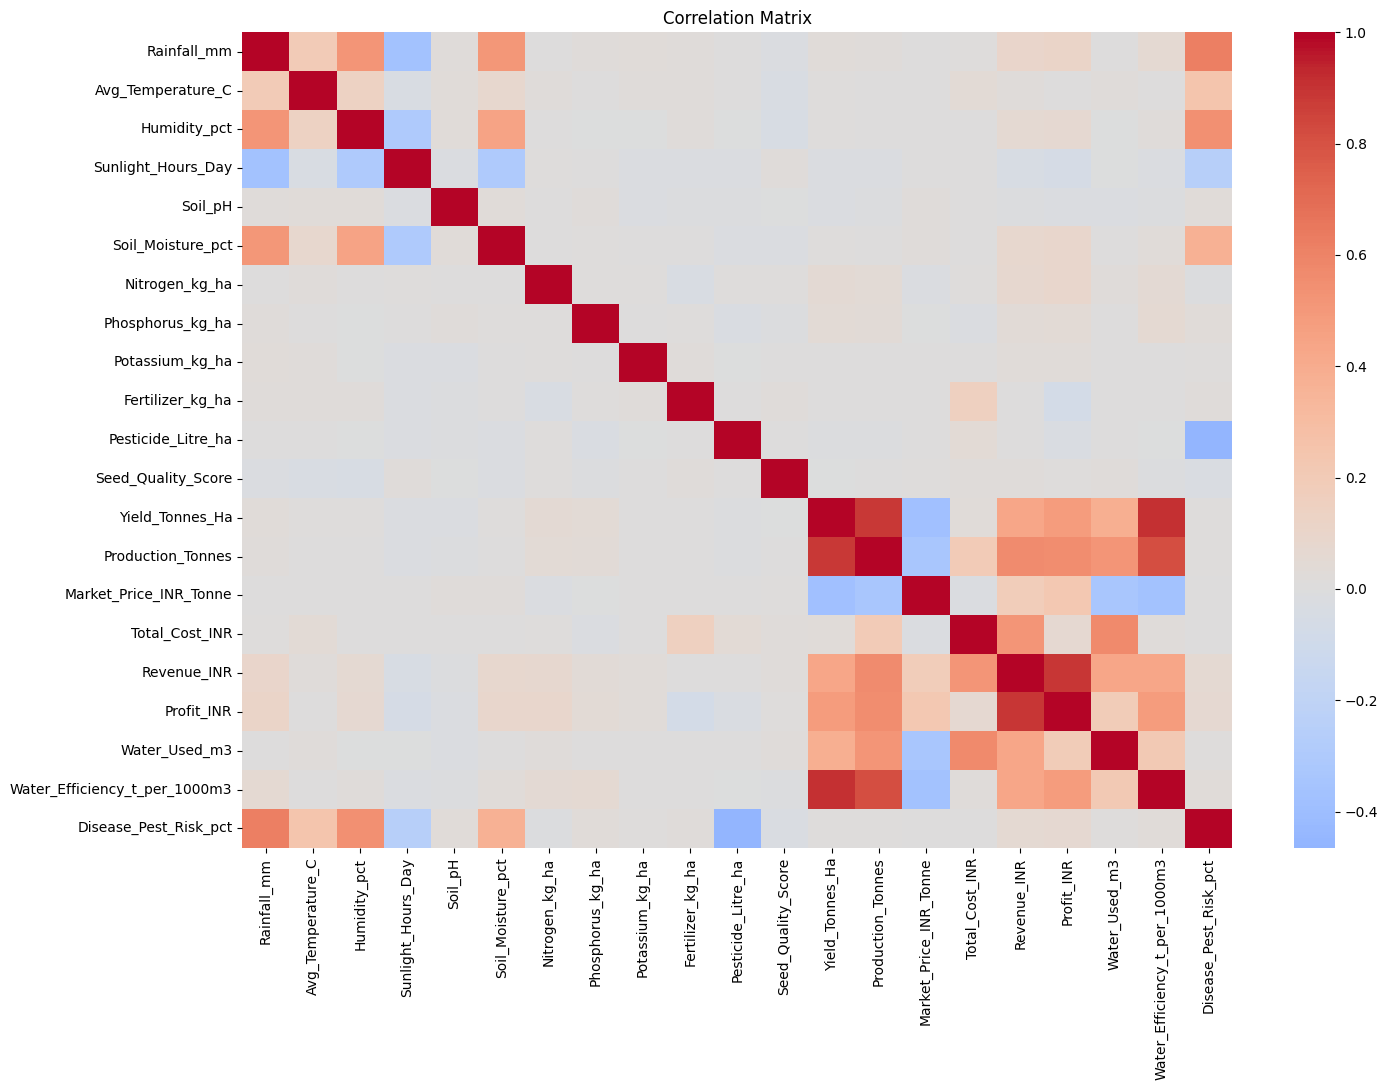

,Correlation
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [ ]:
corr_cols = [
    "Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day",
    "Soil_pH","Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha",
    "Potassium_kg_ha","Fertilizer_kg_ha","Pesticide_Litre_ha",
    "Seed_Quality_Score","Yield_Tonnes_Ha","Production_Tonnes",
    "Market_Price_INR_Tonne","Total_Cost_INR","Revenue_INR","Profit_INR",
    "Water_Used_m3","Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"
]
corr = df[corr_cols].corr()

plt.figure(figsize=(15,11))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

display(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).head(10).to_frame("Correlation"))


In [ ]:
import pandas as pd

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


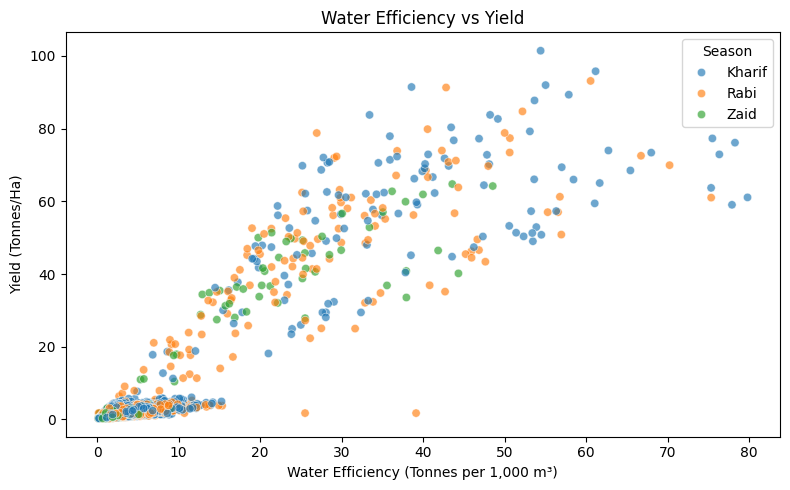

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df, x="Water_Efficiency_t_per_1000m3",
    y="Yield_Tonnes_Ha", hue="Season", alpha=0.65
)
plt.title("Water Efficiency vs Yield")
plt.xlabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 8. Statistical testing — one-way ANOVA

Interpretation:
- **p < 0.05:** evidence that at least one season has a different mean.
- **p ≥ 0.05:** insufficient evidence of a seasonal mean difference.
- Statistical significance does not automatically mean the difference is practically large.


In [ ]:
metrics = [
    "Yield_Tonnes_Ha","Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct","Revenue_INR","Production_Tonnes"
]

rows=[]
for metric in metrics:
    groups=[g[metric].dropna() for _,g in df.groupby("Season")]
    f_stat,p=stats.f_oneway(*groups)
    rows.append([metric,f_stat,p,"Significant" if p < 0.05 else "Not significant"])

anova_results=pd.DataFrame(
    rows, columns=["Metric","F_statistic","p_value","Decision"]
)
display(anova_results.round(6))


,Metric,F_statistic,p_value,Decision
0,Yield_Tonnes_Ha,1.543880,0.213678,Not significant
1,Profit_INR,34.291750,0.000000,Significant
2,Water_Efficiency_t_per_1000m3,6.948270,0.000972,Significant
3,Disease_Pest_Risk_pct,1049.467430,0.000000,Significant
4,Revenue_INR,24.890131,0.000000,Significant
5,Production_Tonnes,1.026225,0.358452,Not significant


## 9. Distribution and outlier analysis

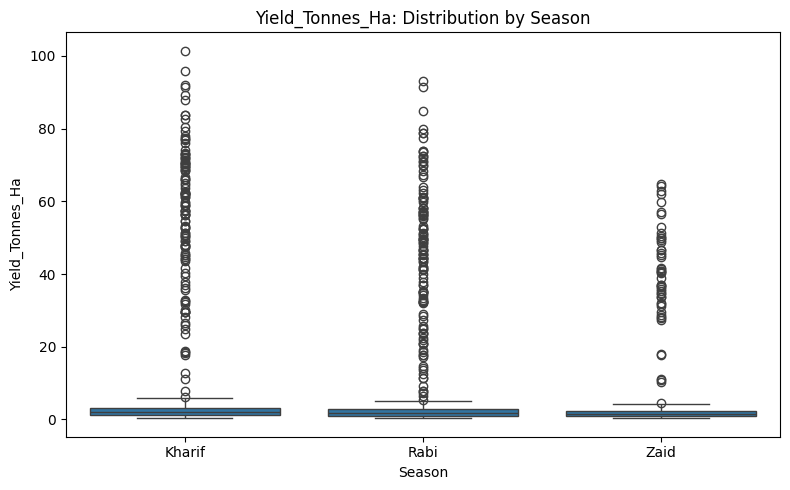

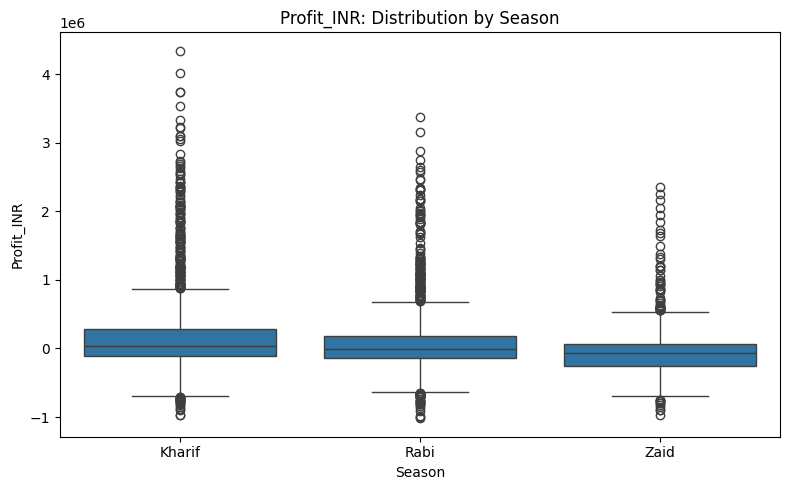

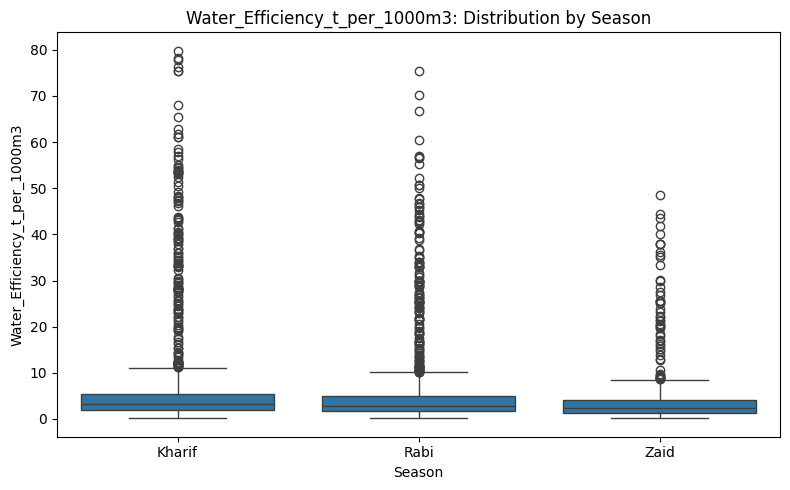

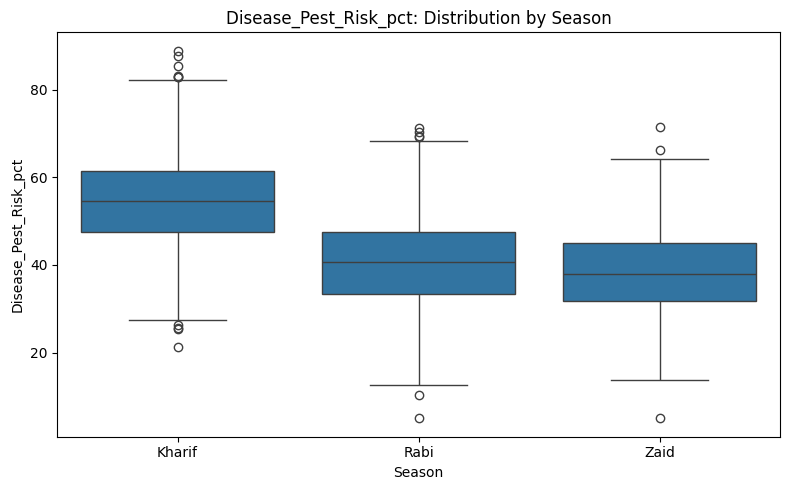

In [ ]:
for col in [
    "Yield_Tonnes_Ha","Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Season", y=col)
    plt.title(f"{col}: Distribution by Season")
    plt.tight_layout()
    plt.show()


## 10. Automatically generate key findings

In [ ]:
season_yield=df.groupby("Season")["Yield_Tonnes_Ha"].mean()
season_profit=df.groupby("Season")["Profit_INR"].mean()
season_water=df.groupby("Season")["Water_Efficiency_t_per_1000m3"].mean()
season_risk=df.groupby("Season")["Disease_Pest_Risk_pct"].mean()
crop_profit=df.groupby("Crop")["Profit_INR"].mean()
irr_yield=df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean()

print("Highest average yield:", season_yield.idxmax(), f"({season_yield.max():.2f} tonnes/ha)")
print("Highest average profit:", season_profit.idxmax(), f"(INR {season_profit.max():,.2f})")
print("Highest water efficiency:", season_water.idxmax(), f"({season_water.max():.2f})")
print("Highest disease/pest risk:", season_risk.idxmax(), f"({season_risk.max():.2f}%)")
print("Most profitable crop:", crop_profit.idxmax(), f"(INR {crop_profit.max():,.2f})")
print("Highest-yield irrigation method:", irr_yield.idxmax(), f"({irr_yield.max():.2f} tonnes/ha)")


Highest average yield: Kharif (5.63 tonnes/ha)
Highest average profit: Kharif (INR 178,914.65)
Highest water efficiency: Kharif (5.89)
Highest disease/pest risk: Kharif (54.47%)
Most profitable crop: Sugarcane (INR 817,187.99)
Highest-yield irrigation method: Drip (6.58 tonnes/ha)


## 11. Conclusion and recommendations

### Conclusion
The project evaluates seasonal agricultural performance using yield, production, profitability, water efficiency, environmental variables and disease/pest risk. The final conclusion should combine descriptive comparisons with the ANOVA results.

### Recommendations
1. Compare crop choice with season before cultivation planning.
2. Prioritize irrigation practices that show better yield/water efficiency in the data.
3. Monitor disease/pest risk in seasons with higher observed risk.
4. Use state- and crop-level comparisons instead of relying only on overall averages.
5. Evaluate profitability along with yield because high yield does not necessarily mean high profit.
6. Treat correlations as associations, not proof of causation.
